# Support Vector Machines

*You are seeing the
notebook output generated by
[Literate.jl](https://github.com/fredrikekre/Literate.jl) from the
[Julia source file](https://github.com/JuliaGaussianProcesses/KernelFunctions.jl/blob/master/examples/support-vector-machine/script.jl).
The rendered HTML can be viewed [in the docs](https://juliagaussianprocesses.github.io/KernelFunctions.jl/dev/examples/support-vector-machine/).*

TODO: introduction

We first load the packages we will need in this notebook:

In [1]:
using KernelFunctions
using Distributions, LinearAlgebra, Random
using Plots;
default(; legendfontsize=15.0, ms=5.0);

# Set plotting theme
theme(:wong)

# Set seed
Random.seed!(1234);

## Data Generation

We first generate a mixture of two Gaussians in 2 dimensions

In [2]:
xmin = -3;
xmax = 3; # Limits for sampling μ₁ and μ₂
μ = rand(Uniform(xmin, xmax), 2, 2) # Sample 2 Random Centers

2×2 Matrix{Float64}:
 0.545068   0.397424
 1.60078   -0.239488

We then sample both the input $x$ and the class $y$:

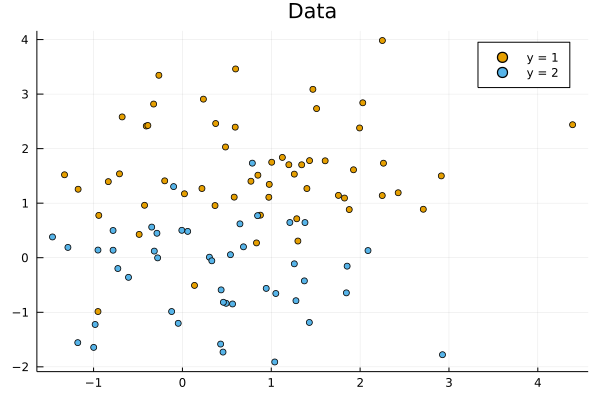

In [3]:
N = 100 # Number of samples
y = rand((-1, 1), N) # Select randomly between the two classes
x = Vector{Vector{Float64}}(undef, N) # We preallocate x
x[y .== 1] = [rand(MvNormal(μ[:, 1], I)) for _ in 1:count(y .== 1)] # Features for samples of class 1
x[y .== -1] = [rand(MvNormal(μ[:, 2], I)) for _ in 1:count(y .== -1)] # Features for samples of class 2
scatter(getindex.(x[y .== 1], 1), getindex.(x[y .== 1], 2); label="y = 1", title="Data")
scatter!(getindex.(x[y .== -1], 1), getindex.(x[y .== -1], 2); label="y = 2")

Number of samples:

In [4]:
#N = 100;

Select randomly between two classes:

In [5]:
#y = rand([-1, 1], N);

Random attributes for both classes:

In [6]:
#X = Matrix{Float64}(undef, 2, N)
#rand!(MvNormal(randn(2), I), view(X, :, y .== 1))
#rand!(MvNormal(randn(2), I), view(X, :, y .== -1));

Create a 2D grid:

In [7]:
#xgrid = range(floor(Int, minimum(X)), ceil(Int, maximum(X)); length=100)
#Xgrid = ColVecs(mapreduce(collect, hcat, Iterators.product(xgrid, xgrid)));

## Model Definition
TODO Write theory here

### Kernel

Create kernel function:

In [8]:
k = SqExponentialKernel() ∘ ScaleTransform(2.0)
λ = 1.0; # Regularization parameter

### Predictor
We create a function to return the optimal prediction for a test data `x_new`

Optimal prediction:

In [9]:
f(x, X, y, k, λ) = kernelmatrix(k, x, X) / (kernelmatrix(k, X) + λ * I) * y;

f(x, X, y, k, λ) = kernelmatrix(k, x, X) * ((kernelmatrix(k, X) + λ * I) \ y)

### Loss
We also compute the total loss of the model that we want to minimize

In [10]:
hingeloss(y, ŷ) = maximum(zero(ŷ), 1 - y * ŷ) # hingeloss function
function reg_hingeloss(k, x, y, λ)
    ŷ = f(x, x, y, k, λ)
    return sum(hingeloss.(y, ŷ)) - λ * norm(ŷ) # Total svm loss with regularisation
end;

### Testing the trained model
We create a 2D grid based on the maximum values of the data

In [11]:
N_test = 100 # Size of the grid
xgrid = range(extrema(vcat(x...)) .* 1.1...; length=N_test) # Create a 1D grid
xgrid_v = vec(collect.(Iterators.product(xgrid, xgrid))); # Combine into a 2D grid

We predict the value of y on this grid on plot it against the data

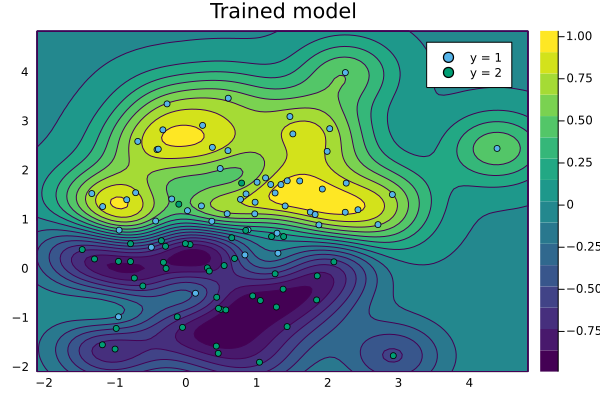

In [12]:
y_grid = f(xgrid_v, x, y, k, λ) # Compute prediction on a grid
contourf(
    xgrid,
    xgrid,
    reshape(y_grid, N_test, N_test)';
    label="Predictions",
    title="Trained model",
)
scatter!(getindex.(x[y .== 1], 1), getindex.(x[y .== 1], 2); label="y = 1")
scatter!(getindex.(x[y .== -1], 1), getindex.(x[y .== -1], 2); label="y = 2")
xlims!(extrema(xgrid))
ylims!(extrema(xgrid))

contourf(xgrid, xgrid, f(Xgrid, ColVecs(X), k, 0.1))
scatter!(X[1, :], X[2, :]; color=y, lab="data", widen=false)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*